# Stochastic simulations

## Gillespie Algorithm

In [1]:
using Plots
using DataInterpolations: LinearInterpolation
using StatsBase: Weights, sample
using Statistics: mean
using Random
using DisplayAs: PNG    ## For faster rendering
Random.seed!(2024)

Random.TaskLocalRNG()

## Do-it-yourself

Stochastic chemical reaction: Gillespie Algorithm (direct and first reaction method)
Adapted from: Chemical and Biomedical Engineering Calculations Using Python Ch.4-3

In [2]:
function ssa_alg(model, u0::AbstractVector, tend, p, stoich; tstart=zero(tend), method=:direct)
    t = tstart   ## Current time
    ts = [t]     ## Time points
    u = copy(u0) ## Current state
    us = copy(u') ## States over time
    while t < tend
        a = model(u, p, t)               ## propensities
        if method == :direct
            dt = randexp() / sum(a)          ## Time step for the direct method
            du = sample(stoich, Weights(a))  ## Choose the stoichiometry for the next reaction
        elseif method == :first
            dts = randexp(length(a)) ./ a   ## time scales of all reactions
            i = argmin(dts)                 ## Choose the most recent reaction to occur
            dt = dts[i]
            du = stoich[i]
        else
            error("Method should be either :direct or :first")
        end
        u .+= du   ## Update time
        t += dt    ## Update time
        us = [us; u']  ## Append state
        push!(ts, t)   ## Append time point
    end
    return (t=ts, u=us)
end

ssa_alg (generic function with 1 method)

Propensity model for this example reaction.
Reaction of A <-> B with rate constants k1 & k2

In [3]:
model(u, p, t) = [p.k1 * u[1], p.k2 * u[2]]

model (generic function with 1 method)

In [4]:
parameters = (k1=1.0, k2=0.5)

(k1 = 1.0, k2 = 0.5)

Stoichiometry for each reaction

In [5]:
stoich = [[-1, 1], [1, -1]]

2-element Vector{Vector{Int64}}:
 [-1, 1]
 [1, -1]

Initial conditions (Usually discrete values)

In [6]:
u0 = [200, 0]

2-element Vector{Int64}:
 200
   0

Simulation time

In [7]:
tend = 10.0

10.0

Solve the problem using both direct and first reaction method

In [8]:
@time soldirect = ssa_alg(model, u0, tend, parameters, stoich; method=:direct)
@time solfirst = ssa_alg(model, u0, tend, parameters, stoich; method=:first)

  1.044179 seconds (783.45 k allocations: 54.729 MiB, 14.99% gc time, 99.22% compilation time)
  0.009261 seconds (16.33 k allocations: 14.929 MiB)


(t = [0.0, 0.006874672879606227, 0.0070050915014185, 0.01329115182676454, 0.015335530116774018, 0.01942319769041779, 0.021346508038833215, 0.02345030020299408, 0.025497753122539372, 0.02734483697039726  …  9.937773197389458, 9.938360255993572, 9.964450740930666, 9.96564917153764, 9.975440668199402, 9.978594329657025, 9.982318425245289, 9.987213207313044, 9.995833233887383, 10.024199143896238], u = [200 0; 199 1; … ; 75 125; 74 126])

Plot the solution from the direct method

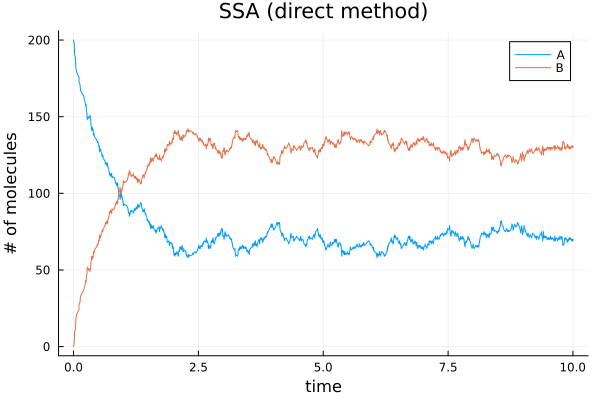

In [9]:
plot(soldirect.t, soldirect.u,
    xlabel="time", ylabel="# of molecules",
    title="SSA (direct method)", label=["A" "B"]) |> PNG

Plot the solution by the first reaction method

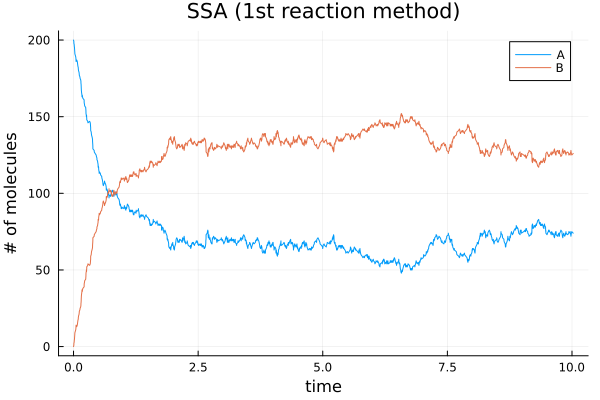

In [10]:
plot(solfirst.t, solfirst.u,
    xlabel="time", ylabel="# of molecules",
    title="SSA (1st reaction method)", label=["A" "B"]) |> PNG

Running 50 simulations

In [11]:
numRuns = 50

@time sols = map(1:numRuns) do _
    ssa_alg(model, u0, tend, parameters, stoich; method=:first)
end;

  0.812526 seconds (1.02 M allocations: 770.311 MiB, 50.01% gc time, 10.26% compilation time)


Average values and interpolation

In [12]:
ts = range(0, tend, 101)
a_avg(t) = mean(sols) do sol
    A = LinearInterpolation(sol.u[:, 1], sol.t)
    A(t)
end

b_avg(t) = mean(sols) do sol
    A = LinearInterpolation(sol.u[:, 2], sol.t)
    A(t)
end

b_avg (generic function with 1 method)

Plot the solution

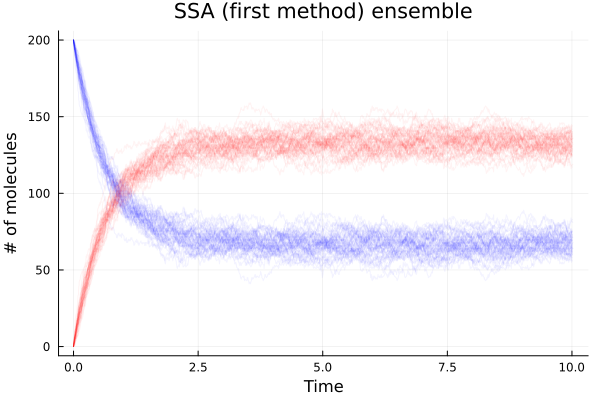

In [13]:
fig1 = plot(xlabel="Time", ylabel="# of molecules", title="SSA (first method) ensemble")

for sol in sols
    plot!(fig1, sol.t, sol.u, linecolor=[:blue :red], linealpha=0.05, label=false)
end

fig1 |> PNG

Plot averages

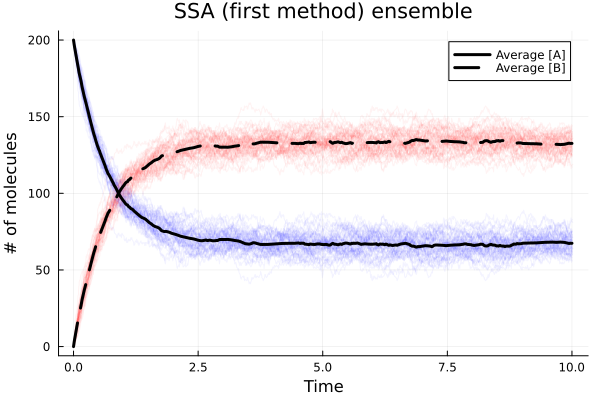

In [14]:
plot!(fig1, a_avg, 0.0, tend, linecolor=:black, linewidth=3, linestyle=:solid, label="Average [A]") |> PNG
plot!(fig1, b_avg, 0.0, tend, linecolor=:black, linewidth=3, linestyle=:dash, label="Average [B]") |> PNG
fig1 |> PNG

## Using Catalyst (recommended)

https://github.com/SciML/Catalyst.jl is a domain-specific language (DSL) package to simulate chemical reaction networks.

In [15]:
using Catalyst
using JumpProcesses
using Plots

two_state_model = @reaction_network begin
    k1, A --> B
    k2, B --> A
end

Precompiling Catalyst...
  21638.4 ms  ✓ Catalyst
  1 dependency successfully precompiled in 22 seconds. 295 already precompiled.
Precompiling DataInterpolationsSymbolicsExt...
   6056.6 ms  ✓ DataInterpolations → DataInterpolationsSymbolicsExt
  1 dependency successfully precompiled in 7 seconds. 164 already precompiled.


Model ##ReactionSystem#240:
Unknowns (2): see unknowns(##ReactionSystem#240)
  A(t)
  B(t)
Parameters (2): see parameters(##ReactionSystem#240)
  k1
  k2

The system with *integer* state variables belongs to `DiscreteProblem`. A `DiscreteProblem` could be further dispatched into other types of problems, such as `ODEProblem`, `SDEProblem`, and `JumpProblem`.

In [16]:
params = [:k1 => 1.0, :k2 => 0.5]
u0 = [:A => 200, :B => 0]
tspan = (0.0, 10.0)
jinput = JumpInputs(two_state_model, u0, tspan, params)

JumpInputs storing
  JumpSystem: ##ReactionSystem#240
  Problem type: DiscreteProblem

In this case, we would like to solve a `JumpProblem` using [Gillespie's Direct stochastic simulation algorithm (SSA)](https://doi.org/10.1016/0021-9991(76)90041-3).

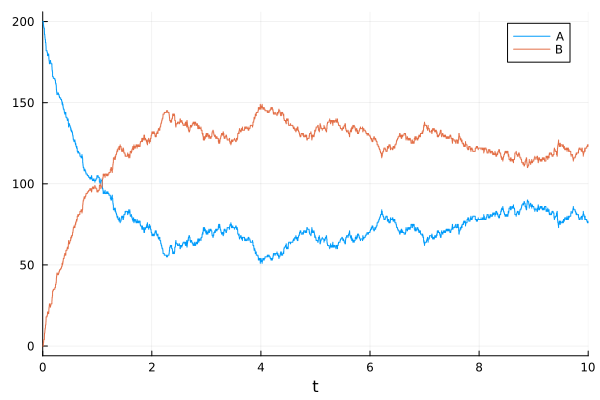

In [17]:
jprob = JumpProblem(jinput)
sol = solve(jprob)
plot(sol) |> PNG

Parallel ensemble simulation

In [18]:
ensprob = EnsembleProblem(jprob)
sim = solve(ensprob, SSAStepper(), EnsembleThreads(); trajectories=50)

EnsembleSolution Solution of length 50 with uType:
SciMLBase.ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Nothing, Nothing, SciMLBase.DiscreteProblem{Vector{Float64}, Tuple{Float64, Float64}, true, ModelingToolkit.MTKParameters{Vector{Float64}, Vector{Float64}, Tuple{}, Tuple{}, Tuple{}, Tuple{}}, SciMLBase.DiscreteFunction{true, true, SciMLBase.DiscreteFunction{true, SciMLBase.FullSpecialize, SciMLBase.var"#246#247", Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing}, Nothing, ModelingToolkit.ObservedFunctionCache{ModelingToolkit.JumpSystem{RecursiveArrayTools.ArrayPartition{Any, Tuple{Vector{JumpProcesses.MassActionJump}, Vector{JumpProcesses.ConstantRateJump}, Vector{JumpProcesses.VariableRateJump}, Vector{Symbolics.Equation}}}}}, ModelingToolkit.JumpSystem{RecursiveArrayTools.ArrayPartition{Any, Tuple{Vector{JumpProcesses.MassActionJump}, Vector{JumpProcesses.ConstantRateJump}, Vector{JumpProcesses.VariableRateJump}, Vector{Symboli

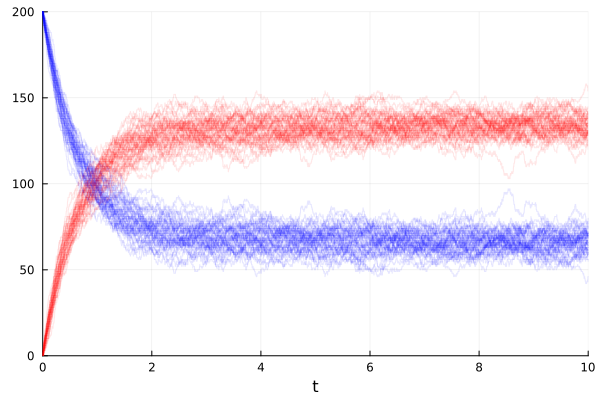

In [19]:
plot(sim, alpha=0.1, color=[:blue :red]) |> PNG

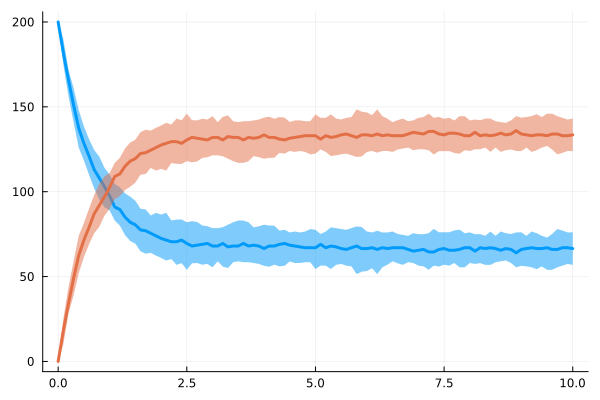

In [20]:
summ = EnsembleSummary(sim, 0:0.1:10)
plot(summ, fillalpha=0.5) |> PNG

**See also** the [JumpProcesses.jl docs](https://docs.sciml.ai/JumpProcesses/stable/api/#JumpProcesses.ConstantRateJump) about discrete stochastic examples.
- High-level solutions using `Catalyst.jl` and low-level solutions defining the jumps directly.
- Coupling stochastic discrete jumping and ODEs.
- `RegularJumps` using a more efficient tau-leaping method.
- [More solvers](https://docs.sciml.ai/JumpProcesses/stable/jump_types/) for discrete stochastic simulations.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*